# 2.15 Caso Práctico: Análisis Visual del Dataset FIFA 23

**Aplicación de visualizaciones comunes y avanzadas a un dataset real**

Sergio Alejandro Holguín García

---

En las clases anteriores vimos los **tipos de gráficos** y las **buenas prácticas de visualización**. Ahora vamos a aplicarlos a un dataset real: **18.539 jugadores de FIFA 23**, con 89 atributos cada uno (overall, potencial, valor de mercado, estadísticas técnicas, club, nacionalidad, etc.).

El enfoque del notebook es **responder preguntas de negocio con visualizaciones**: cada sección plantea una pregunta y muestra el gráfico que mejor la responde, mezclando los comunes (barras, líneas, histograma) con los menos comunes (mapa coroplético, treemap, radar, hexbin, sunburst).
[Base de datos](https://drive.google.com/file/d/1PkH5bYRe2d0f-5HBmdVP7qFQc9oru5S0/view?usp=drive_link)
## Preguntas que vamos a resolver

1. ¿Cómo se distribuye el nivel general (overall) de los jugadores?
2. ¿Qué nacionalidades aportan más jugadores al fútbol mundial?
3. ¿Qué países producen jugadores con mejor calidad promedio? (mapa)
4. ¿Cómo se relacionan la edad y el overall?
5. ¿Qué pie preferido predomina?
6. ¿Cómo cambia el overall según la posición en el campo?
7. ¿Quiénes son los 10 jugadores más caros del mundo?
8. ¿Qué relación hay entre overall y valor de mercado?
9. ¿Cómo se comparan los perfiles de los 4 mejores delanteros? (radar)
10. ¿Qué clubes concentran más valor en su plantilla? (treemap)
11. ¿Cómo se correlacionan las estadísticas técnicas?
12. ¿Cuál es el potencial de crecimiento por edad?

---

## 0. Configuración inicial y carga del dataset

In [6]:
# Si alguna librería no está instalada, descomenta:
!pip install plotly squarify

# Librerías base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
import plotly.express as px
import plotly.graph_objects as go

# Configuración estética general
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titleweight'] = 'bold'

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


In [8]:
# Cargar el dataset (asumimos que el CSV está en la misma carpeta del notebook)
df = pd.read_csv('/content/Fifa 23 Players Data.csv')

# Información básica
print(f'Filas: {len(df):,}  |  Columnas: {df.shape[1]}')
print(f'Memoria: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

# Vista de las primeras columnas
df[['Known As', 'Overall', 'Potential', 'Value(in Euro)',
    'Best Position', 'Nationality', 'Age', 'Club Name']].head()

Filas: 18,539  |  Columnas: 89
Memoria: 30.0 MB


,Known As,Overall,Potential,Value(in Euro),Best Position,Nationality,Age,Club Name
0,L. Messi,91,91,54000000,CAM,Argentina,35,Paris Saint-Germain
1,K. Benzema,91,91,64000000,CF,France,34,Real Madrid CF
2,R. Lewandowski,91,91,84000000,ST,Poland,33,FC Barcelona
3,K. De Bruyne,91,91,107500000,CM,Belgium,31,Manchester City
4,K. Mbappé,91,95,190500000,ST,France,23,Paris Saint-Germain


### Limpieza rápida

Antes de visualizar conviene revisar el estado de los datos: tipos, nulos, valores extremos.

In [9]:
# Resumen rápido de variables clave
cols_resumen = ['Overall', 'Potential', 'Value(in Euro)',
                'Wage(in Euro)', 'Age', 'Height(in cm)', 'Weight(in kg)']
df[cols_resumen].describe().round(1)

,Overall,Potential,Value(in Euro),Wage(in Euro),Age,Height(in cm),Weight(in kg)
count,18539.0,18539.0,18539.0,18539.0,18539.0,18539.0,18539.0
mean,65.9,71.0,2875461.4,8824.5,25.2,181.6,75.2
std,6.8,6.2,7635128.9,19460.5,4.7,6.9,7.0
min,47.0,48.0,0.0,0.0,16.0,155.0,49.0
25%,62.0,67.0,475000.0,1000.0,21.0,177.0,70.0
50%,66.0,71.0,1000000.0,3000.0,25.0,182.0,75.0
75%,70.0,75.0,2000000.0,8000.0,29.0,186.0,80.0
max,91.0,95.0,190500000.0,450000.0,44.0,206.0,105.0


In [10]:
# Valores nulos: ¿hay columnas con problemas?
nulos = df.isnull().sum()
print('Columnas con valores nulos:')
print(nulos[nulos > 0] if nulos.sum() > 0 else 'Ninguna columna tiene nulos')

Columnas con valores nulos:
Ninguna columna tiene nulos


El dataset está limpio. Pasamos directo a las preguntas.

---

## Pregunta 1: ¿Cómo se distribuye el nivel general (overall) de los jugadores?

**Gráfico apropiado:** histograma. Es la herramienta natural para ver la **forma de la distribución** de una variable numérica continua.

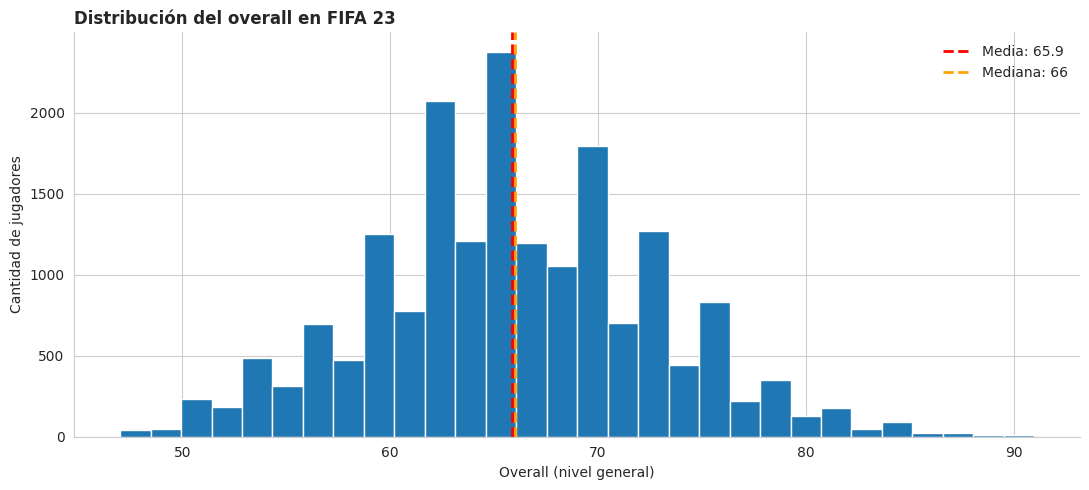

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))

# Histograma con 30 intervalos
ax.hist(df['Overall'], bins=30,
        color='#1f77b4', edgecolor='white')

# Líneas de referencia: media y mediana
media   = df['Overall'].mean()
mediana = df['Overall'].median()

ax.axvline(media,   color='red',    linestyle='--', linewidth=2,
           label=f'Media: {media:.1f}')
ax.axvline(mediana, color='orange', linestyle='--', linewidth=2,
           label=f'Mediana: {mediana:.0f}')

ax.set_title('Distribución del overall en FIFA 23', loc='left')
ax.set_xlabel('Overall (nivel general)')
ax.set_ylabel('Cantidad de jugadores')
ax.legend(frameon=False)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Respuesta:** la distribución se concentra entre 60-70 con forma aproximadamente normal. Solo un puñado de jugadores supera el 85, lo que confirma que la **excelencia es escasa**: los Messi y Mbappé son la cola derecha de una campana enorme.

---
## Pregunta 2: ¿Qué nacionalidades aportan más jugadores al fútbol mundial?

**Gráfico apropiado:** barras horizontales. Como los nombres de los países son largos, la versión horizontal facilita la lectura. Mostramos solo el top 15 (filtramos lo irrelevante, principio de "mostrar solo lo importante").

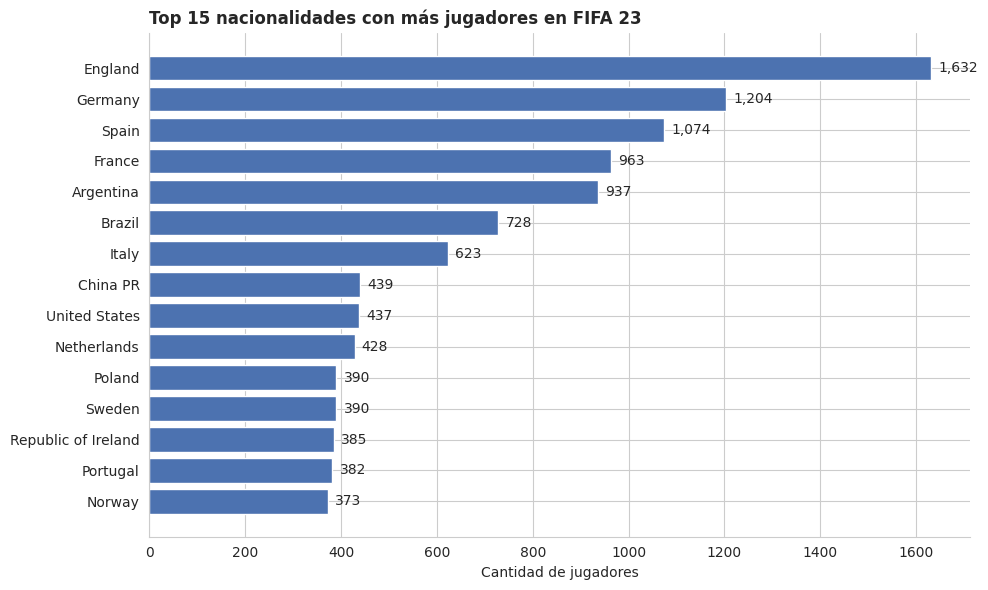

In [12]:
# Top 15 nacionalidades por cantidad de jugadores
top_paises = df['Nationality'].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top_paises.index, top_paises.values, color='#4c72b0')

# Etiqueta con el valor al final de cada barra
for i, v in enumerate(top_paises.values):
    ax.text(v + 15, i, f'{v:,}', va='center', fontsize=10)

ax.set_title('Top 15 nacionalidades con más jugadores en FIFA 23', loc='left')
ax.set_xlabel('Cantidad de jugadores')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Respuesta:** Inglaterra lidera con más de 1.600 jugadores, seguida por Alemania y España. Esto refleja la fortaleza de las ligas locales y la profundidad del fútbol europeo.

---
## Pregunta 3: ¿Qué países producen jugadores con mejor calidad promedio?

**Gráfico apropiado:** mapa coroplético. La pregunta tiene una dimensión geográfica natural, así que el mapa lo deja todo claro de un vistazo.

**Importante:** filtramos países con al menos 30 jugadores para evitar que naciones con 1 o 2 jugadores estrella distorsionen el promedio.

In [13]:
# Calcular overall promedio por país (solo países con >= 30 jugadores)
stats_pais = df.groupby('Nationality').agg(
    overall_medio=('Overall', 'mean'),
    cantidad=('Overall', 'count')
).reset_index()

stats_pais = stats_pais[stats_pais['cantidad'] >= 30]
stats_pais['overall_medio'] = stats_pais['overall_medio'].round(1)

# Plotly mapea países por nombre, pero algunos tienen distinto formato.
# Usamos el modo 'country names' que es robusto.
fig = px.choropleth(
    stats_pais,
    locations='Nationality', locationmode='country names',
    color='overall_medio',
    hover_name='Nationality',
    hover_data={'cantidad': True, 'Nationality': False},
    color_continuous_scale='RdYlGn',     # rojo (bajo) a verde (alto)
    title='Overall promedio por país (mín. 30 jugadores)',
    labels={'overall_medio': 'Overall medio'},
)
fig.update_layout(width=950, height=550, margin=dict(l=10, r=10, t=50, b=10))
fig.show()

**Respuesta:** los países con verdes más intensos (Brasil, Argentina, España, Francia, Alemania) producen jugadores de mayor calidad media. Pasa el mouse para ver el dato exacto y cuántos jugadores aporta cada país.

---
## Pregunta 4: ¿Cómo se relacionan la edad y el overall?

**Gráfico apropiado:** dispersión (scatter plot). Pregunta clásica de correlación entre dos variables numéricas. Como tenemos 18.539 puntos, agregamos transparencia para evitar saturación.

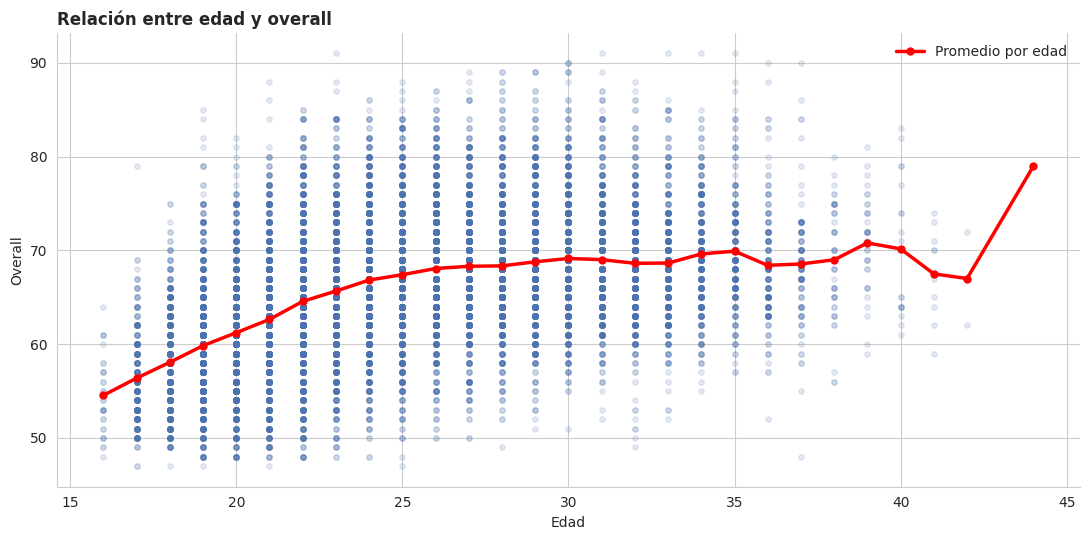

In [14]:
fig, ax = plt.subplots(figsize=(11, 5.5))

# Scatter con alpha bajo para que se vea la densidad
ax.scatter(df['Age'], df['Overall'],
           alpha=0.15, s=15, color='#4c72b0')

# Calcular el overall MEDIO por edad y trazar una línea de tendencia
tendencia = df.groupby('Age')['Overall'].mean()
ax.plot(tendencia.index, tendencia.values,
        color='red', linewidth=2.5, marker='o', markersize=5,
        label='Promedio por edad')

ax.set_title('Relación entre edad y overall', loc='left')
ax.set_xlabel('Edad')
ax.set_ylabel('Overall')
ax.legend(frameon=False)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Respuesta:** la línea roja muestra el patrón típico de una carrera deportiva: el overall **sube hasta los 30-32 años** (pico de carrera) y luego **baja**. Los jugadores jóvenes (16-20) son mayoría pero con valores bajos; los veteranos son pocos pero con valores muy variables.

---
## Pregunta 5: ¿Qué pie preferido predomina entre los jugadores?

**Gráfico apropiado:** circular (pastel). Solo hay 2 categorías (izquierdo/derecho), así que el pastel funciona perfectamente.

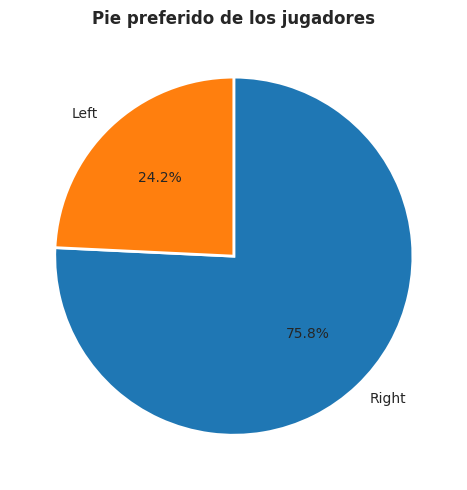

Diestros: 14,045 (75.8%)
Zurdos:   4,494 (24.2%)


In [15]:
pie_counts = df['Preferred Foot'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))

ax.pie(pie_counts.values, labels=pie_counts.index,
       autopct='%1.1f%%',
       colors=['#1f77b4', '#ff7f0e'],
       startangle=90, counterclock=False,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})

ax.set_title('Pie preferido de los jugadores')
plt.tight_layout()
plt.show()

print(f'Diestros: {pie_counts["Right"]:,} ({pie_counts["Right"]/len(df)*100:.1f}%)')
print(f'Zurdos:   {pie_counts["Left"]:,} ({pie_counts["Left"]/len(df)*100:.1f}%)')

**Respuesta:** el ~76% son diestros y solo ~24% son zurdos, una proporción muy similar a la de la población general. Los jugadores zurdos son escasos, lo que explica por qué suelen ser cotizados (Messi, Maradona, Cruyff).

---
## Pregunta 6: ¿Cómo cambia el overall según la posición en el campo?

**Gráfico apropiado:** **violin plot**. Un box plot serviría, pero el violin nos muestra además la **forma de la distribución**, lo que revela si una posición tiene jugadores muy concentrados o muy variados.

/tmp/ipykernel_8335/2065024171.py:17: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




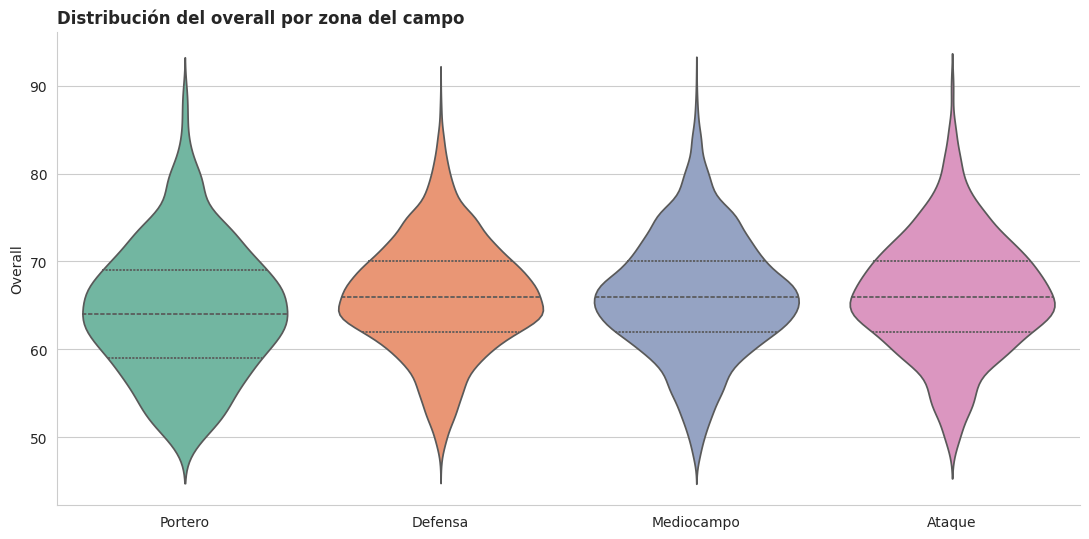

In [16]:
# Agrupamos posiciones en categorías más amplias (defensa, mediocampo, ataque, portero)
mapa_posicion = {
    'GK': 'Portero',
    'CB': 'Defensa', 'LB': 'Defensa', 'RB': 'Defensa',
    'LWB': 'Defensa', 'RWB': 'Defensa',
    'CDM': 'Mediocampo', 'CM': 'Mediocampo', 'CAM': 'Mediocampo',
    'LM': 'Mediocampo', 'RM': 'Mediocampo',
    'LW': 'Ataque', 'RW': 'Ataque', 'CF': 'Ataque', 'ST': 'Ataque',
}
df['Zona'] = df['Best Position'].map(mapa_posicion)

# Orden lógico de las zonas
orden_zonas = ['Portero', 'Defensa', 'Mediocampo', 'Ataque']

fig, ax = plt.subplots(figsize=(11, 5.5))

sns.violinplot(
    data=df, x='Zona', y='Overall',
    order=orden_zonas,
    palette='Set2',
    inner='quartile',
    ax=ax,
)

ax.set_title('Distribución del overall por zona del campo', loc='left')
ax.set_xlabel('')
ax.set_ylabel('Overall')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Respuesta:** las cuatro zonas tienen distribuciones muy parecidas en mediana, pero los **delanteros y mediocampistas** tienen colas superiores más largas: la "élite" (overall > 85) está concentrada en posiciones ofensivas. Los porteros se ven muy compactos en el rango medio.

---
## Pregunta 7: ¿Quiénes son los 10 jugadores más caros del mundo?

**Gráfico apropiado:** barras horizontales. Los nombres son largos y queremos un ranking claro.

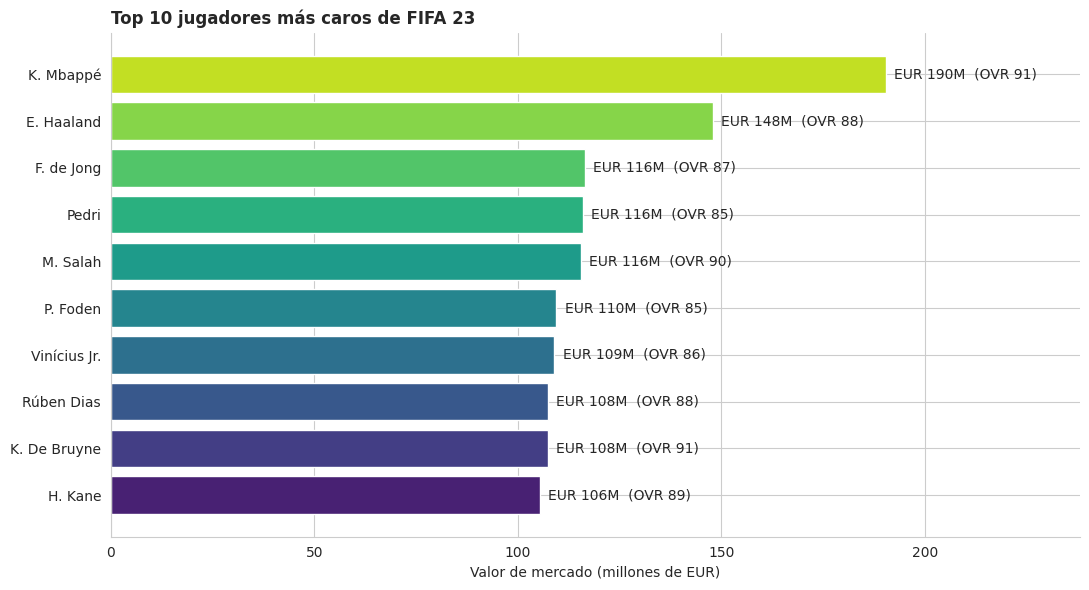

In [17]:
# Ordenar por valor de mercado y tomar el top 10
top10 = df.nlargest(10, 'Value(in Euro)')[
    ['Known As', 'Value(in Euro)', 'Overall', 'Club Name', 'Age']
].sort_values('Value(in Euro)')

# Convertir valores a millones para mejor lectura
top10['Valor_M'] = top10['Value(in Euro)'] / 1e6

fig, ax = plt.subplots(figsize=(11, 6))

# Color escalado según el valor (cuanto más caro, más oscuro)
colores = sns.color_palette('viridis', len(top10))
ax.barh(top10['Known As'], top10['Valor_M'], color=colores)

# Etiqueta al final de cada barra: valor en millones + overall
for i, (nombre, valor, ovr, club) in enumerate(
        zip(top10['Known As'], top10['Valor_M'], top10['Overall'], top10['Club Name'])):
    ax.text(valor + 2, i, f'EUR {valor:.0f}M  (OVR {ovr})',
            va='center', fontsize=10)

ax.set_title('Top 10 jugadores más caros de FIFA 23', loc='left')
ax.set_xlabel('Valor de mercado (millones de EUR)')
ax.set_xlim(0, top10['Valor_M'].max() * 1.25)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Respuesta:** Mbappé encabeza el ranking, seguido por Haaland y Vinicius Jr. Lo interesante: el top está dominado por jugadores **jóvenes con potencial**, no necesariamente por los de mayor overall actual.

---
## Pregunta 8: ¿Qué relación hay entre overall y valor de mercado?

**Gráfico apropiado:** **hexbin plot**. Con 18.539 jugadores un scatter común quedaría completamente saturado. El hexbin agrupa los puntos en hexágonos coloreados según la densidad.

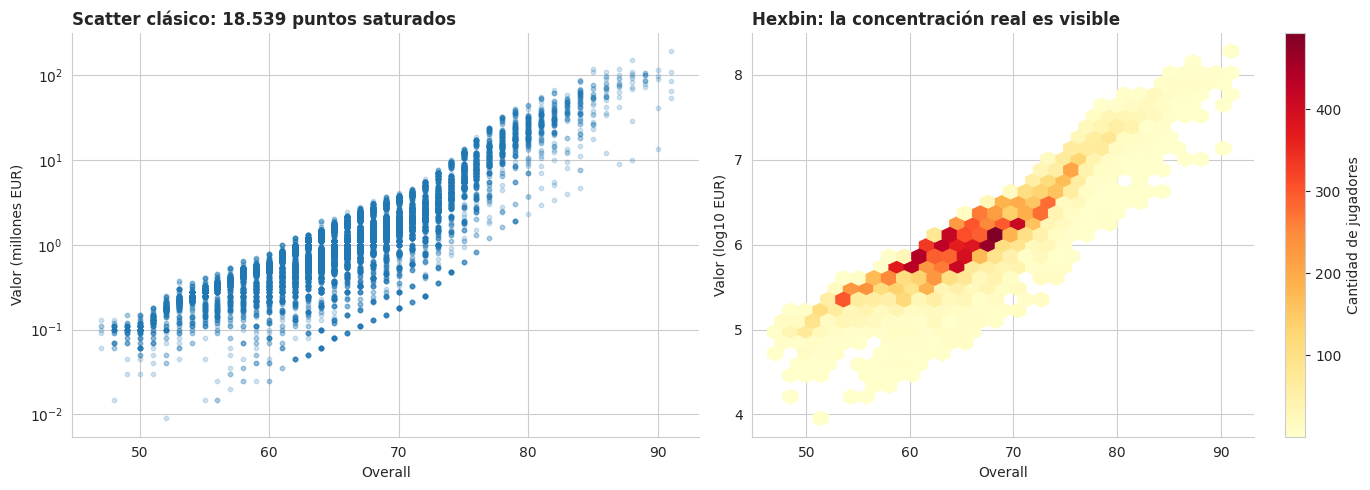

Correlación entre Overall y log(Valor): 0.887


In [18]:
# Filtramos jugadores con valor > 0 para usar escala logarítmica
df_valor = df[df['Value(in Euro)'] > 0].copy()
df_valor['Valor_log'] = np.log10(df_valor['Value(in Euro)'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter clásico: queda saturado
axes[0].scatter(df_valor['Overall'], df_valor['Value(in Euro)'] / 1e6,
                alpha=0.2, s=10)
axes[0].set_title('Scatter clásico: 18.539 puntos saturados', loc='left')
axes[0].set_xlabel('Overall')
axes[0].set_ylabel('Valor (millones EUR)')
axes[0].set_yscale('log')

# Hexbin: la densidad se ve clara
hb = axes[1].hexbin(df_valor['Overall'], df_valor['Valor_log'],
                    gridsize=30, cmap='YlOrRd', mincnt=1)
axes[1].set_title('Hexbin: la concentración real es visible', loc='left')
axes[1].set_xlabel('Overall')
axes[1].set_ylabel('Valor (log10 EUR)')
fig.colorbar(hb, ax=axes[1], label='Cantidad de jugadores')

for ax in axes:
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

# Coeficiente de correlación
corr = df_valor['Overall'].corr(df_valor['Valor_log'])
print(f'Correlación entre Overall y log(Valor): {corr:.3f}')

**Respuesta:** la correlación es muy fuerte (~0,90). Pero la relación **no es lineal**: cada punto adicional de overall multiplica el valor (por eso el eje Y va en log). Pasar de 80 a 85 vale mucho más que pasar de 60 a 65.

---
## Pregunta 9: ¿Cómo se comparan los perfiles de los 4 mejores delanteros?

**Gráfico apropiado:** **radar chart**. Tenemos 6 atributos (las 6 estadísticas FIFA) y queremos comparar varios jugadores al mismo tiempo. Es el caso de uso clásico del radar.

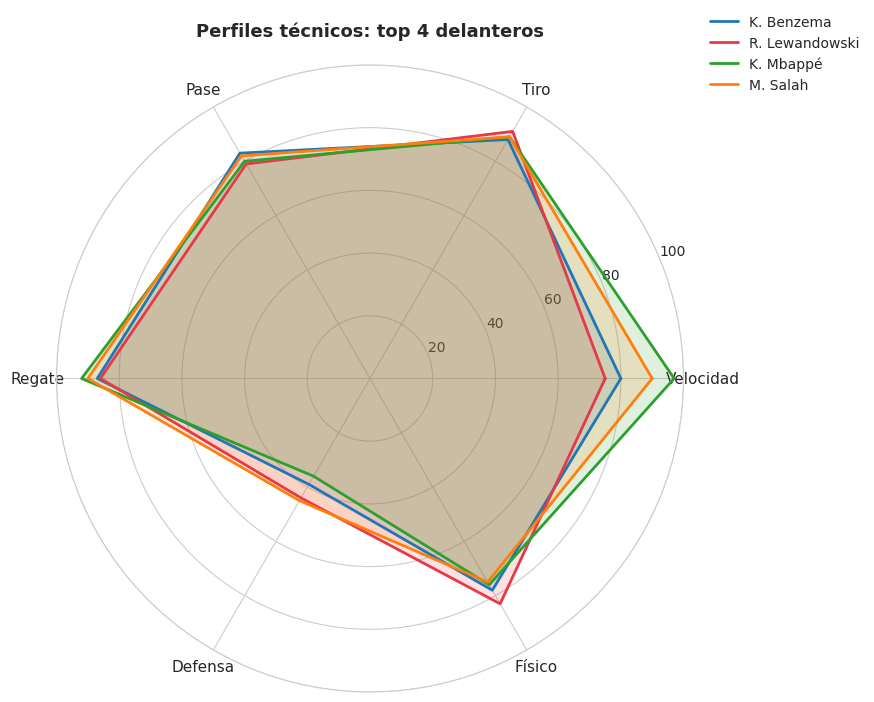

In [19]:
# Tomamos los 4 mejores delanteros (zona Ataque) por overall
delanteros = df[df['Zona'] == 'Ataque'].nlargest(4, 'Overall')

# Las 6 estadísticas principales FIFA
stats = ['Pace Total', 'Shooting Total', 'Passing Total',
         'Dribbling Total', 'Defending Total', 'Physicality Total']
labels_stats = ['Velocidad', 'Tiro', 'Pase',
                'Regate', 'Defensa', 'Físico']

# Ángulos para cada eje del radar
n = len(stats)
angulos = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
angulos += angulos[:1]   # cerrar el polígono

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
colores = ['#1f77b4', '#e63946', '#2ca02c', '#ff7f0e']

for (_, jugador), color in zip(delanteros.iterrows(), colores):
    valores = jugador[stats].tolist()
    valores += valores[:1]   # cerrar polígono
    ax.plot(angulos, valores, color=color, linewidth=2, label=jugador['Known As'])
    ax.fill(angulos, valores, color=color, alpha=0.15)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(labels_stats, fontsize=11)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_title('Perfiles técnicos: top 4 delanteros\n', fontsize=13)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), frameon=False)

plt.tight_layout()
plt.show()

**Respuesta:** la "huella" de cada jugador revela su perfil. Algunos sobresalen en velocidad y regate, otros en tiro y físico. La forma del polígono permite identificar rápidamente fortalezas y debilidades relativas.

---
## Pregunta 10: ¿Qué clubes concentran más valor en su plantilla?

**Gráfico apropiado:** **treemap**. Queremos ver "partes de un total" con muchos elementos. Un pastel con 20 categorías sería ilegible; el treemap funciona bien.

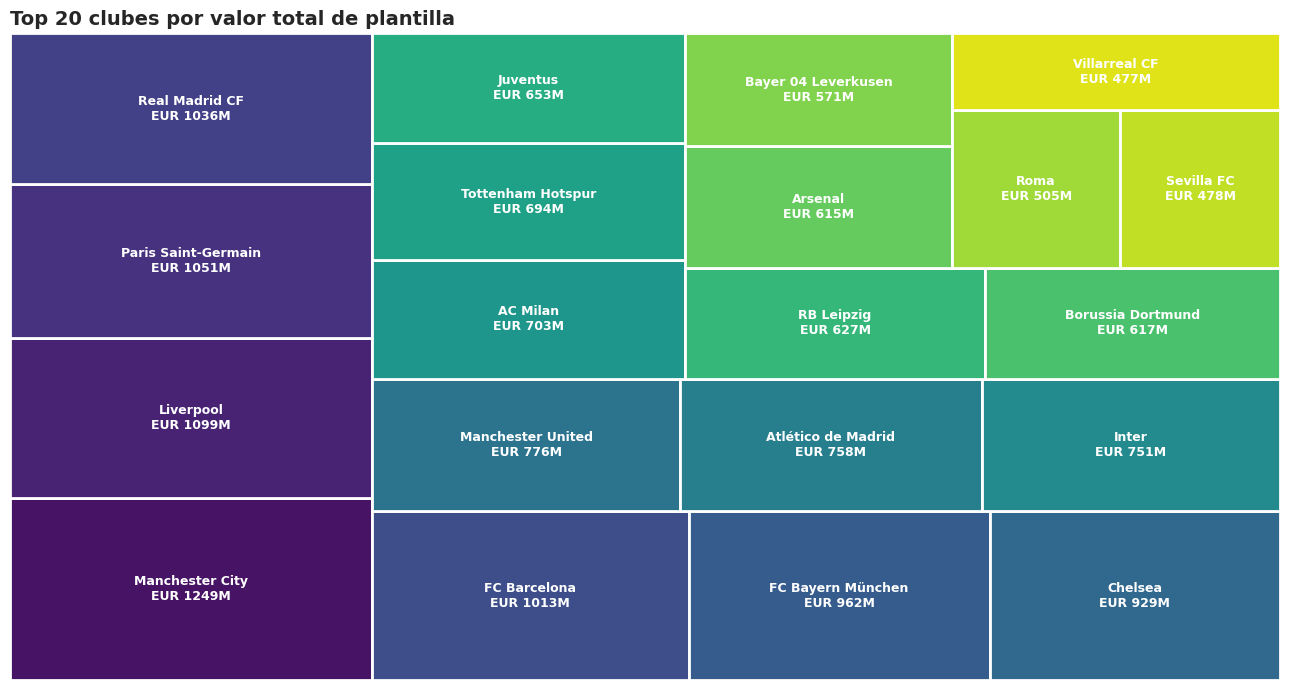

In [20]:
# Suma del valor de mercado por club, top 20
valor_clubs = (df.groupby('Club Name')['Value(in Euro)']
                 .sum()
                 .sort_values(ascending=False)
                 .head(20)) / 1e6   # en millones EUR

# Etiquetas: club + valor en millones
etiquetas = [f'{club}\nEUR {v:.0f}M' for club, v in valor_clubs.items()]

fig, ax = plt.subplots(figsize=(13, 7))

squarify.plot(
    sizes=valor_clubs.values,
    label=etiquetas,
    color=sns.color_palette('viridis', len(valor_clubs)),
    text_kwargs={'fontsize': 9, 'color': 'white', 'fontweight': 'bold'},
    edgecolor='white', linewidth=2,
    ax=ax,
)

ax.set_title('Top 20 clubes por valor total de plantilla', loc='left', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

**Respuesta:** Manchester City lidera, seguido por Liverpool, PSG, Real Madrid y Barcelona. Los 5 primeros clubes acumulan más de 5.000 millones de euros en plantilla. El tamaño relativo de cada rectángulo permite comparar de forma intuitiva.

---
## Pregunta 11: ¿Cómo se correlacionan las estadísticas técnicas?

**Gráfico apropiado:** **heatmap de correlaciones**. Cuando hay muchas variables numéricas, este gráfico revela qué pares se mueven juntos. Es estándar en análisis exploratorio.

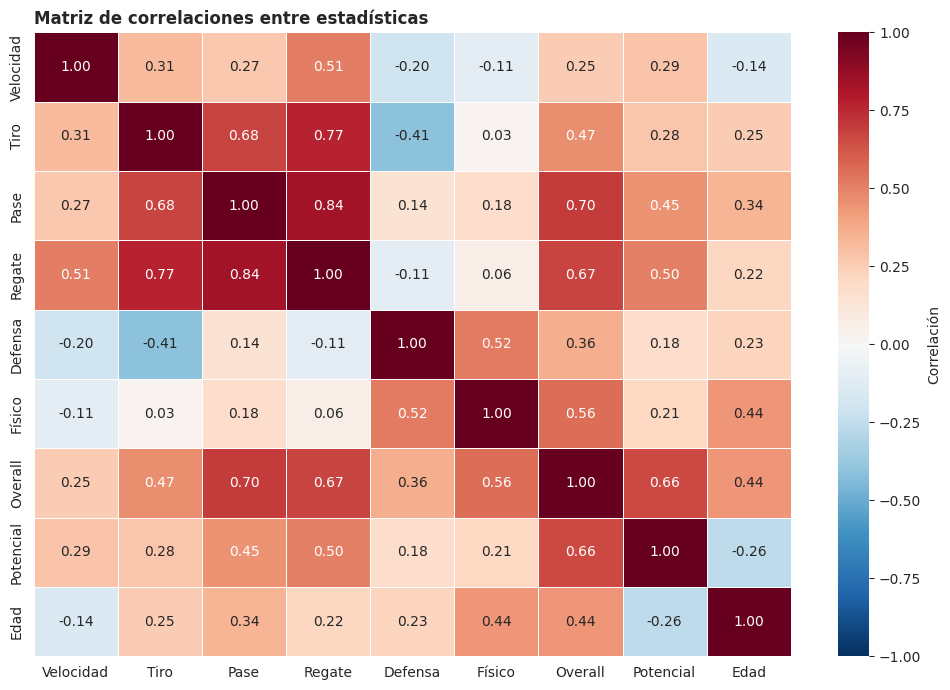

In [21]:
# Stats técnicas a analizar
stats_corr = ['Pace Total', 'Shooting Total', 'Passing Total',
              'Dribbling Total', 'Defending Total', 'Physicality Total',
              'Overall', 'Potential', 'Age']

# Renombrar para que las etiquetas se lean en español
rename_map = {
    'Pace Total': 'Velocidad', 'Shooting Total': 'Tiro',
    'Passing Total': 'Pase',     'Dribbling Total': 'Regate',
    'Defending Total': 'Defensa', 'Physicality Total': 'Físico',
    'Overall': 'Overall', 'Potential': 'Potencial', 'Age': 'Edad',
}

matriz_corr = df[stats_corr].rename(columns=rename_map).corr()

fig, ax = plt.subplots(figsize=(10, 7))

# Paleta divergente: rojo (correlación negativa) - blanco (cero) - azul (positiva)
sns.heatmap(matriz_corr,
            annot=True, fmt='.2f',
            cmap='RdBu_r', center=0,
            vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Correlación'},
            ax=ax)

ax.set_title('Matriz de correlaciones entre estadísticas', loc='left')
plt.tight_layout()
plt.show()

**Respuesta:**
- **Defensa** se correlaciona negativamente con tiro, regate y velocidad: confirma que defensores y atacantes tienen perfiles opuestos.
- **Tiro y regate** están fuertemente correlacionados: los buenos atacantes son ambos.
- **Edad** apenas se correlaciona con stats técnicas, pero **negativamente con potencial** (cuanto mayor el jugador, menos potencial de crecer).

---
## Pregunta 12: ¿Cuál es el potencial de crecimiento por edad?

**Gráfico apropiado:** scatter con dos series superpuestas (overall actual vs potencial), agregadas por edad. Permite responder: *¿hasta qué edad puede un jugador todavía mejorar?*

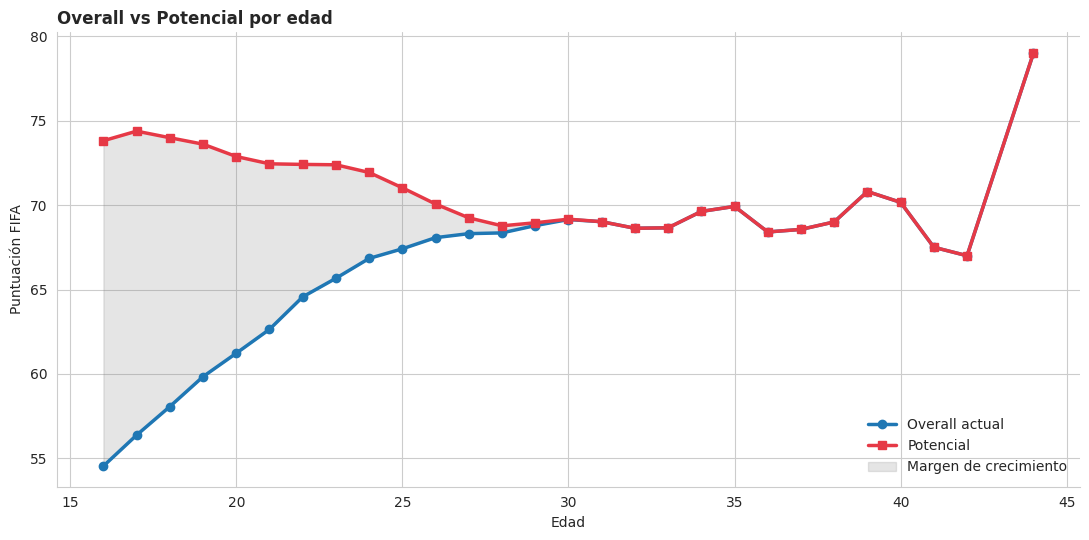

In [22]:
# Calculamos overall medio y potencial medio para cada edad
evol = df.groupby('Age').agg(
    overall_medio=('Overall', 'mean'),
    potencial_medio=('Potential', 'mean'),
    n_jugadores=('Overall', 'count'),
).reset_index()

# La diferencia es el "margen de crecimiento"
evol['gap'] = evol['potencial_medio'] - evol['overall_medio']

fig, ax = plt.subplots(figsize=(11, 5.5))

# Dos líneas: overall actual y potencial
ax.plot(evol['Age'], evol['overall_medio'],
        color='#1f77b4', linewidth=2.5, marker='o',
        label='Overall actual')
ax.plot(evol['Age'], evol['potencial_medio'],
        color='#e63946', linewidth=2.5, marker='s',
        label='Potencial')

# Sombrear la zona de crecimiento (gap entre las líneas)
ax.fill_between(evol['Age'],
                evol['overall_medio'], evol['potencial_medio'],
                color='gray', alpha=0.2,
                label='Margen de crecimiento')

ax.set_title('Overall vs Potencial por edad', loc='left')
ax.set_xlabel('Edad')
ax.set_ylabel('Puntuación FIFA')
ax.legend(frameon=False, loc='lower right')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

**Respuesta:** la zona gris (margen de crecimiento) es **enorme entre los 16-22 años** y se cierra completamente alrededor de los 28-30. Esa es exactamente la lógica de mercado: los clubes pagan fortunas por jóvenes porque tienen recorrido para crecer.

---
## Bonus: dashboard combinado de un jugador

Para cerrar, combinamos varios gráficos en una sola figura para crear una **"ficha visual"** del mejor jugador del juego.

Jugador analizado: L. Messi (Paris Saint-Germain)


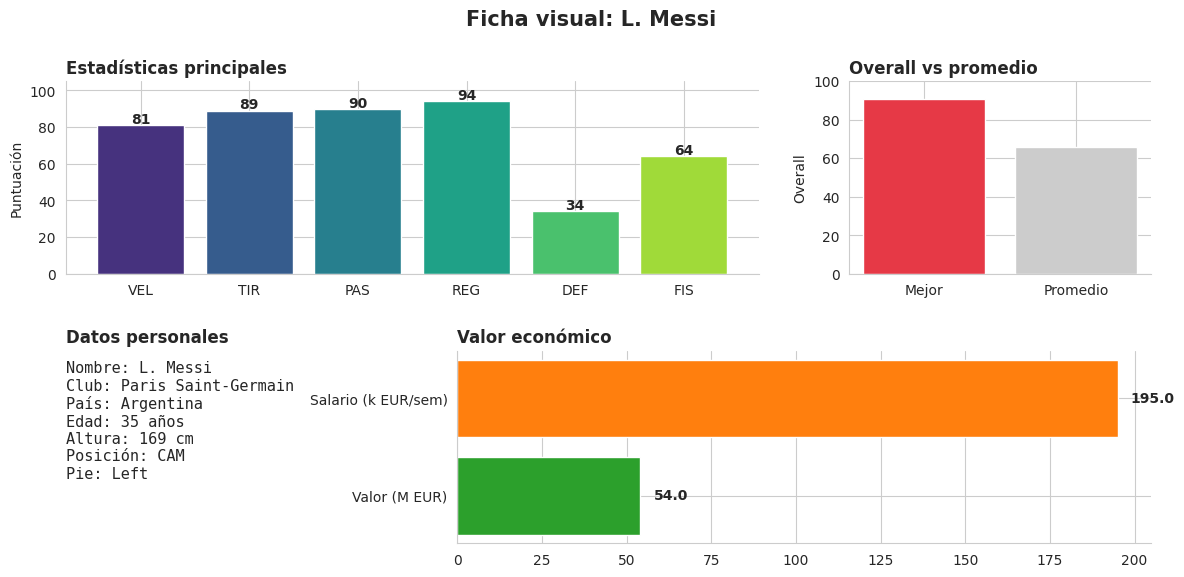

In [23]:
# El jugador con mayor overall
mejor = df.nlargest(1, 'Overall').iloc[0]
print(f'Jugador analizado: {mejor["Known As"]} ({mejor["Club Name"]})')

# Crear figura con grilla de subgráficos
fig = plt.figure(figsize=(14, 6))
gs  = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.3)

# (1) Stats principales como barras
ax1 = fig.add_subplot(gs[0, :2])
stats = ['Pace Total', 'Shooting Total', 'Passing Total',
         'Dribbling Total', 'Defending Total', 'Physicality Total']
labels = ['VEL', 'TIR', 'PAS', 'REG', 'DEF', 'FIS']
valores = [mejor[s] for s in stats]

barras = ax1.bar(labels, valores, color=sns.color_palette('viridis', 6))
for b, v in zip(barras, valores):
    ax1.text(b.get_x() + b.get_width()/2, v + 1, str(v),
             ha='center', fontweight='bold')
ax1.set_ylim(0, 105)
ax1.set_title('Estadísticas principales', loc='left')
ax1.set_ylabel('Puntuación')
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)

# (2) Comparación con la media de su posición
ax2 = fig.add_subplot(gs[0, 2])
media_pos = df[df['Best Position'] == mejor['Best Position']][stats].mean()
ax2.bar(['Mejor', 'Promedio'], [mejor['Overall'], df['Overall'].mean()],
        color=['#e63946', '#cccccc'])
ax2.set_ylim(0, 100)
ax2.set_title(f'Overall vs promedio', loc='left')
ax2.set_ylabel('Overall')
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

# (3) Texto con datos personales
ax3 = fig.add_subplot(gs[1, 0])
ax3.axis('off')
info = (f"Nombre: {mejor['Known As']}\n"
        f"Club: {mejor['Club Name']}\n"
        f"País: {mejor['Nationality']}\n"
        f"Edad: {mejor['Age']} años\n"
        f"Altura: {mejor['Height(in cm)']} cm\n"
        f"Posición: {mejor['Best Position']}\n"
        f"Pie: {mejor['Preferred Foot']}")
ax3.text(0, 0.95, info, fontsize=11, va='top', family='monospace')
ax3.set_title('Datos personales', loc='left')

# (4) Valor de mercado y salario
ax4 = fig.add_subplot(gs[1, 1:])
valor   = mejor['Value(in Euro)'] / 1e6
salario = mejor['Wage(in Euro)'] / 1e3
barras2 = ax4.barh(['Valor (M EUR)', 'Salario (k EUR/sem)'],
                   [valor, salario],
                   color=['#2ca02c', '#ff7f0e'])
for b, v in zip(barras2, [valor, salario]):
    ax4.text(v + max(valor, salario)*0.02, b.get_y() + b.get_height()/2,
             f'{v:.1f}', va='center', fontweight='bold')
ax4.set_title('Valor económico', loc='left')
for spine in ['top', 'right']:
    ax4.spines[spine].set_visible(False)

fig.suptitle(f'Ficha visual: {mejor["Known As"]}',
             fontsize=15, fontweight='bold', y=1.0)
plt.show()

---
## Resumen del análisis

Aplicamos 12 visualizaciones distintas a un dataset de 18.539 jugadores. Cada una respondió una pregunta concreta:

| # | Pregunta | Gráfico usado |
|---|---|---|
| 1 | ¿Cómo se distribuye el overall? | Histograma |
| 2 | ¿Qué países tienen más jugadores? | Barras horizontales |
| 3 | ¿Qué países tienen mejor calidad? | Mapa coroplético |
| 4 | ¿Edad y overall están relacionados? | Scatter + tendencia |
| 5 | ¿Pie preferido predominante? | Pastel |
| 6 | ¿Overall por zona del campo? | Violin plot |
| 7 | ¿Top 10 jugadores más caros? | Barras horizontales |
| 8 | ¿Overall vs valor de mercado? | Hexbin (por densidad) |
| 9 | ¿Comparación de delanteros élite? | Radar chart |
| 10 | ¿Clubes con más valor? | Treemap |
| 11 | ¿Correlación entre stats? | Heatmap |
| 12 | ¿Margen de crecimiento por edad? | Líneas con área sombreada |

### Conclusiones clave del dataset

- La calidad de los jugadores se distribuye casi como una campana centrada en 65 puntos.
- Inglaterra, Alemania y España dominan en cantidad; Brasil y Argentina destacan en calidad media.
- El valor de mercado crece de forma **exponencial** con el overall: cada punto adicional vale mucho más que el anterior.
- La ventana de "crecimiento esperado" se cierra alrededor de los 28-30 años.
- Los clubes top de Europa concentran una porción enorme del valor mundial.

### Lecciones de visualización

1. **Filtrar es parte de visualizar**: top 10, top 15, top 20. Nadie quiere ver 18.539 nombres.
2. **Cuando hay muchos puntos, usa hexbin** o agrega información con líneas de promedio.
3. **Los mapas no son adorno**: cuando la pregunta es geográfica, el mapa siempre gana.
4. **Cada pregunta tiene su gráfico ideal**, no a la inversa.

---

**Universidad Autónoma de Manizales — ¿Especialización en IA**

*Sergio Alejandro Holguín García*